Úloha 1: Lineární a nelineární oscilátory

V této úloze analyzuji chování klasického tlumeného pružinového oscilátoru (lineární systém) a Duffingova oscilátoru, který vykazuje nelineární a chaotické chování.

Tento skript řeší lineární tlumený oscilátor a nelineární Duffingův oscilátor pomocí knihovny : scipy.integrate.odeint

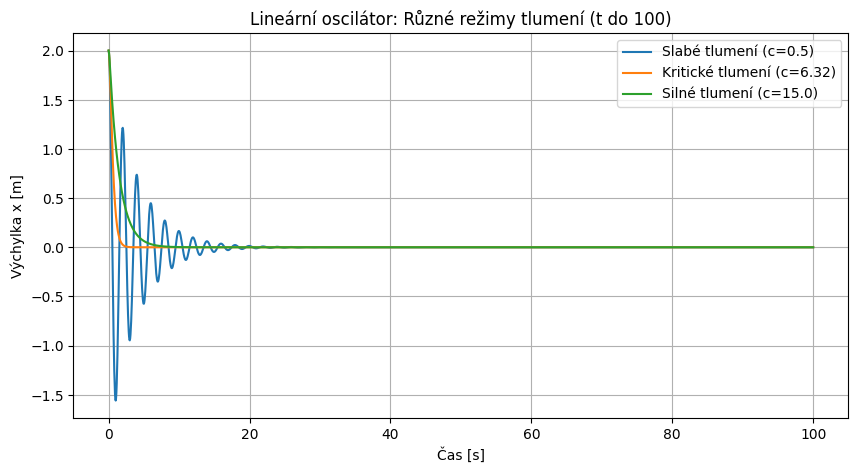

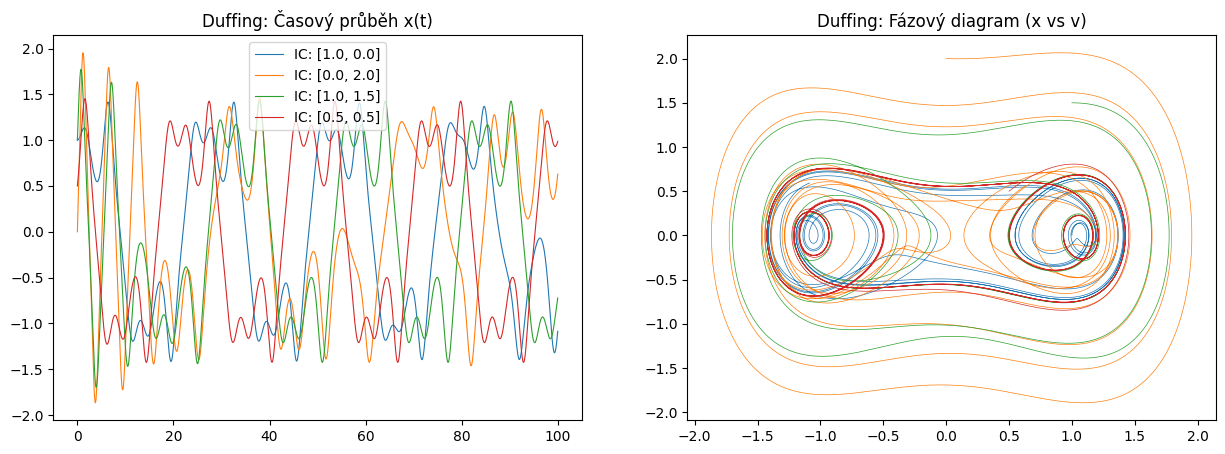

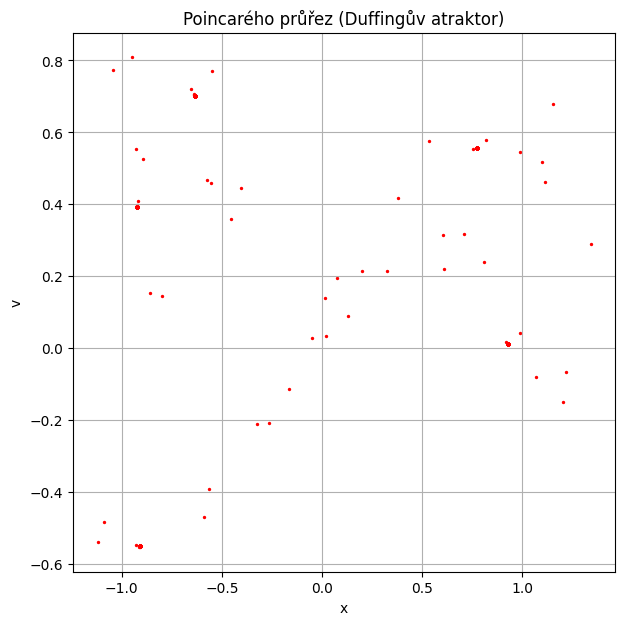

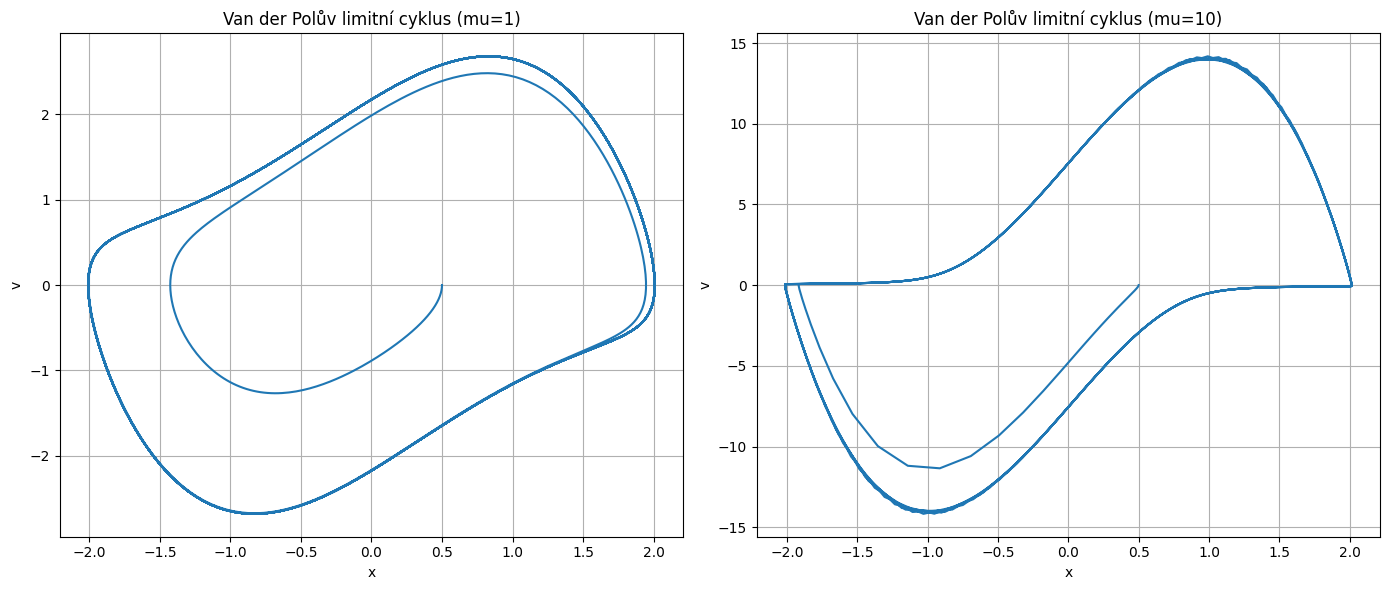

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Poznámka k implementaci: Pro numerické řešení využíváme knihovnu scipy (funkce odeint), 
# která interně používá LSODA – adaptivní metodu pro řešení ODE (založenou na metodách typu Runge-Kutta a Adams). 

# =================================================================
# 1. LINEÁRNÍ OSCILÁTOR
# =================================================================
def linear_oscillator(y, t, m, c, k):
    x, v = y
    return [v, -(c/m)*v - (k/m)*x]

t_lin = np.linspace(0, 100, 2000) # Prodlouženo na t=100 dle zadání 
m, k = 1.0, 10.0
y0_lin = [2.0, 0.0]

plt.figure(figsize=(10, 5))
for c, label in [(0.5, 'Slabé'), (6.32, 'Kritické'), (15.0, 'Silné')]:
    sol = odeint(linear_oscillator, y0_lin, t_lin, args=(m, c, k))
    plt.plot(t_lin, sol[:, 0], label=f'{label} tlumení (c={c})')

plt.title('Lineární oscilátor: Různé režimy tlumení (t do 100)')
plt.xlabel('Čas [s]'); plt.ylabel('Výchylka x [m]')
plt.legend(); plt.grid(True)
plt.show()

# =================================================================
# 2. DUFFINGŮV OSCILÁTOR (Nelineární)
# =================================================================
def duffing(y, t, delta, alpha, beta, gamma, omega):
    x, v = y
    return [v, -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)]

# Parametry ze zadání [cite: 48]
delta, alpha, beta, gamma, omega = 0.2, -1.0, 1.0, 0.3, 1.2
t_duff = np.linspace(0, 100, 10000)

# Více počátečních podmínek (výchylka, rychlost, oboje) 
ics = [[1.0, 0.0], [0.0, 2.0], [1.0, 1.5], [0.5, 0.5]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for y0 in ics:
    sol = odeint(duffing, y0, t_duff, args=(delta, alpha, beta, gamma, omega))
    # x(t) - časový průběh [cite: 25]
    ax1.plot(t_duff, sol[:, 0], lw=0.8, label=f'IC: {y0}')
    # fázový diagram (x vs v) [cite: 26]
    ax2.plot(sol[:, 0], sol[:, 1], lw=0.5)

ax1.set_title('Duffing: Časový průběh x(t)'); ax1.legend()
ax2.set_title('Duffing: Fázový diagram (x vs v)')
plt.show()

# --- POINCARÉHO PRŮŘEZ (Specifický požadavek) --- 
T = 2 * np.pi / omega
t_poincare = np.arange(0, 2000 * T, T) # Vzorkování v čase t=nT
sol_p = odeint(duffing, [0.1, 0.0], t_poincare, args=(delta, alpha, beta, gamma, omega))

plt.figure(figsize=(7, 7))
plt.scatter(sol_p[100:, 0], sol_p[100:, 1], s=2, color='red') # Vynechán začátek (přechodový jev)
plt.title('Poincarého průřez (Duffingův atraktor)')
plt.xlabel('x'); plt.ylabel('v'); plt.grid(True)
plt.show()

# =================================================================
# 3. VAN DER POLŮV OSCILÁTOR (Nelineární) [cite: 11]
# =================================================================
def vdp_oscillator(y, t, mu):
    x, v = y
    return [v, mu * (1 - x**2) * v - x]

t_vdp = np.linspace(0, 100, 5000)

plt.figure(figsize=(14, 6))
for i, mu in enumerate([1, 10]): # mu=1 a mu=10 [cite: 51, 52]
    sol = odeint(vdp_oscillator, [0.5, 0.0], t_vdp, args=(mu,))
    
    plt.subplot(1, 2, i+1)
    plt.plot(sol[:, 0], sol[:, 1])
    plt.title(f'Van der Polův limitní cyklus (mu={mu})')
    plt.xlabel('x'); plt.ylabel('v'); plt.grid(True)

plt.tight_layout()
plt.show()

Otázky:


A) Lineární oscilátor

    Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?

        Slabé (Underdamped): Systém vykonává kmity, jejichž amplituda postupně klesá v čase. V mém grafu je to vidět jako modrá vlnovka.
        Kritické (Critical): Systém se vrátí do rovnováhy nejrychleji bez překmitu. Je to hraniční stav mezi kmitavým a nekmitavým pohybem.
        Silné (Overdamped): Tlumení je tak velké, že návrat do rovnováhy trvá velmi dlouho (systém je "přetlumený").

    Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo
    kvalitativně ostrý?

        Přechod mezi těmito režimy je z hlediska matematiky plynulý (změna kořenů charakteristické rovnice), ale z hlediska chování systému je kvalitativně ostrý – buď systém kmitá, nebo ne.

    Jaký mechanismus vede k rezonanci u buzeného kmitání?

        Rezonance nastává u buzeného kmitání, když se frekvence vnější síly Omega přiblíží vlastní frekvenci oscilátoru Omega. Dochází k maximálnímu přenosu energie do systému a drastickému nárůstu amplitudy.
    
    Dá se problém řešit pomocí symbolické matematiky? Jak?

        Ano, lineární oscilátory lze řešit pomocí knihovny sympy. Protože jde o lineární ODE s konstantními koeficienty, lze analyticky vyjádřit přesnou funkci

B) Duffing

    Dochází pro dané parametry k chaotickému chování?

        Při doporučených parametrech vykazuje systém chaotické chování. To je patrné z fázového diagramu, kde se trajektorie neuzavírá do jednoduchého cyklu, ale tvoří složitý atraktor.
    
    Jaký je rozdíl mezi malou a velkou počáteční podmínkou?

        Rozdíl mezi malou a velkou počáteční podmínkou je v tomto nelineárním systému zásadní. Malá výchylka může způsobit, že systém zůstane v jednom z lokálních minim, zatímco velká výchylka mu dodá energii k "přeskakování" mezi potenciálovými jámami.
    
    Co se stane, když zvýšíte buzení γ? 

         Pokud zvýšíme amplitudu buzení γ, systém získává více energie, což typicky vede k rozbití stabilních limitních cyklů a přechodu do plně chaotického režimu. Počet atraktorů se může měnit (např. splynutí dvou nesouměrných atraktorů v jeden velký chaotický).

    Mění se počet atraktorů?

        Ano, počet atraktorů se v nelineárním systému mění v závislosti na parametrech, zejména na síle buzení

C) Van der Pol

    Jak se mění tvar limitního cyklu při přechodu z μ = 1 na μ = 10?

        Při μ=1 má limitní cyklus téměř kruhový nebo eliptický tvar. Systém se chová podobně jako klasický harmonický oscilátor, kde jsou kmity hladké a sinusové.
        Při μ=10 se tvar cyklu drasticky deformuje na tzv. relaxační oscilace. Limitní cyklus získá v fázovém diagramu „hranatý“ tvar připomínající obdélník se zaoblenými rohy.  

    Proč při velkém μ vznikají rychlé skoky a pomalé fáze?

        Tyto rozdíly v rychlosti vznikají kvůli silné nelinearitě systému, kdy se při velkém μ střídají úseky, kde tlumení pohyb téměř zastaví, s úseky, kde systém náhle ztratí stabilitu. V grafu to pak vypadá tak, že trajektorie dlouho „leze“ po straně a pak bleskově přeskočí na druhou stranu.

    Jaký je vliv počátečních podmínek na konečné chování?
    
        U Van der Polova modelu mají počáteční podmínky na konečný výsledek nulový vliv, protože systém je vždy „vtažen“ do stejného ustáleného stavu. Ať začneš s jakoukoli výchylkou nebo rychlostí, trajektorie nakonec skončí na identickém limitním cyklu.

    Existuje v modelu více atraktorů?

        V tomto modelu typicky více atraktorů neexistuje; vyskytuje se zde pouze jeden stabilní limitní cyklus. Počátek souřadnic (bod nula) funguje jako odpuzovač, který každou trajektorii vyžene směrem k tomuto jedinému dominantnímu atraktoru.


